In [2]:
%matplotlib inline
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from scipy import stats
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [3]:
"""
You can start the code from here
"""
#Import the actual data
df_biofilm_filtered = pd.read_csv('Figurewise raw data/Biofilm_filtered.csv', index_col = 0)
df_biofilm_filtered.head()

,3,8,28,32,42,64,70,78,100,108,...,t_27_enrichment,t_39_enrichment,t_45_enrichment,t_63_enrichment,t_73_enrichment,t_81_enrichment,t_99_enrichment,t_107_enrichment,t_115_enrichment,t_137_enrichment
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0,1,7,3,1,0,3,1,3,3,...,0.301030,0.602060,0.301030,0.602060,1.255273,1.146128,0.903090,0.000000,0.000000,0.000000
ACTGGAGAGACGCTCCAAGT,0,5,1,0,2,0,1,2,0,0,...,0.301030,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030,0.000000
GTTTTTAAATGTGTGCCCGG,1,4,1,3,9,0,4,0,0,0,...,-0.301030,-0.301030,0.397940,0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030
GTACTAAATTGATGCCCATT,10,0,0,0,0,0,0,2,3,0,...,-0.740363,-1.041393,-1.041393,-0.740363,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393
GGCCAAAGTACCTGTTAAAT,7,4,4,4,6,10,5,9,3,4,...,-0.903090,-0.425969,0.096910,-0.903090,-0.903090,-0.425969,-0.903090,-0.903090,-0.425969,-0.903090


In [4]:
"""
In the following code, we just simulate a simple singular bottleneck.
As we show below, a simple bottleneck does not explain our results.
"""

#Simulating a simple bottleneck
"""
The following code is to make the calibration curve to estimate the simple bottleneck size:
"""
N_list = 10**np.arange(0,8,0.5)
list_N = []
list_N_std = []
for N in N_list:
    list_n_i = []
    for i in range(0,10):
        Sim = np.random.multinomial(N, df_biofilm_filtered['t_3_f'], size = 1)[0].transpose()
        Sim_measured = np.random.multinomial(250000, Sim/sum(Sim), size = 1)[0].transpose()
        list_n_i.append(len(Sim_measured[Sim_measured > 0]))
    list_N.append(np.mean(list_n_i))
    list_N_std.append(np.std(list_n_i))

In [5]:
"""
Using the linear part of the calibratio curve, we estimate the parameters to calculate the bottleneck size
"""

import numpy as np
from sklearn.linear_model import LinearRegression


x = np.log10(list_N)[0:10].reshape((-1, 1))
y = np.arange(0,8,0.5)[0:10]
model = LinearRegression()
model.fit(x, y)
model = LinearRegression().fit(x, y)

print(f"intercept: {model.intercept_}")
print(f"slope: {model.coef_}")


"""
Using the actual data of the number of unique barcodes identified, we measure the bottleneck size
"""

arra_nb = np.array([22141,18795,16564,17668,18117,21986,27598,11576,13945,29065,18049,29122])
results = model.predict(np.log10(arra_nb).reshape((-1, 1)))

bottlenecksize = []
for result in results:
    bottlenecksize.append(10**result)
print("Mean bottleneck size 0s = " + str(round(np.mean(bottlenecksize))))

intercept: -0.013377765602144986
slope: [1.01792718]
Mean bottleneck size 0s = 23631


In [7]:
df_uniqbarcodes = pd.read_csv('Figurewise raw data/1C.Number_of_barcodes.csv', index_col=0)

#Estimating the number of unique barcodes for the flask
mean_flask = np.mean(df_uniqbarcodes.loc[df_uniqbarcodes.Source == 'Flask'].Nb)
std_flask = np.std(df_uniqbarcodes.loc[df_uniqbarcodes.Source == 'Flask'].Nb)

#Estimating the number of unique barcodes for the planktonic population
mean_plank = np.mean(df_uniqbarcodes.loc[df_uniqbarcodes.Source == 'Planktonic'].Nb)
std_plank = np.std(df_uniqbarcodes.loc[df_uniqbarcodes.Source == 'Planktonic'].Nb)

#Estimating the number of unique barcodes for the barcodes
mean_disc = np.mean(df_uniqbarcodes.loc[df_uniqbarcodes.Source == 'Disc'].Nb)
std_disc = np.std(df_uniqbarcodes.loc[df_uniqbarcodes.Source == 'Disc'].Nb)

print(mean_flask,std_flask,mean_plank,std_plank,mean_disc,std_disc)

74268.5 6345.683907192352 76383.75 8170.1123118045325 20388.583333333332 5493.928913784945


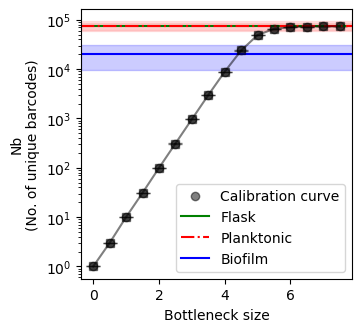

In [8]:
"""
Here we plot the simulation for the simple bottleneck.
In addition, we plot the mean and range of values for number of unique barcodes in 
the disc, flask population, and the planktonic population.
"""


plt.figure(figsize=[3.5,3.5])
plt.errorbar(np.arange(0,8,0.5), list_N, yerr= list_N_std, marker='s', color = 'black', alpha = 0.5 ,capsize=5, elinewidth=2)
plt.plot(np.arange(0,8,0.5), list_N, 'o', label = 'Calibration curve', color = 'black', alpha = 0.5)


plt.yscale('log', base =10)
plt.ylabel('Nb\n(No. of unique barcodes)')
plt.xlabel('Bottleneck size')
#plt.axhline(y = 21608.58333)

plt.axhline(y = mean_flask, color = 'green', label = 'Flask')
plt.axhspan(mean_flask-(1.96*std_flask), mean_flask+(1.96*std_flask), color = 'red', alpha = 0.1)

plt.axhline(y = mean_plank, color = 'red', linestyle = '-.', label = 'Planktonic')
plt.axhspan(mean_plank-(1.96*std_plank), mean_plank+(1.96*std_plank), color = 'red', alpha = 0.1)

plt.axhline(y = mean_disc, color = 'blue', label = 'Biofilm')
plt.axhspan(mean_disc-(1.96*std_disc), mean_disc+(1.96*std_disc), color = 'blue', alpha = 0.2)

plt.legend()

plt.savefig('Figures paper/Simple model/Simple bottleneck model.svg', format = 'svg', dpi = 300)

In [10]:
Sim = np.random.multinomial(20388, df_biofilm_filtered['t_3_f'], size = 1)[0].transpose()
Sim_measured = np.random.multinomial(250000, Sim/sum(Sim), size = 1)[0].transpose()
sum(Sim_measured)

np.int32(250000)

C:\Users\achoudhu\AppData\Local\Temp\ipykernel_30616\3961065226.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\achoudhu\AppData\Local\Temp\ipykernel_30616\3961065226.py:24: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('Figures paper/Simple model/Simple comparison_'+disc+'.svg', format = 'svg', dpi = 300)
C:\Users\achoudhu\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


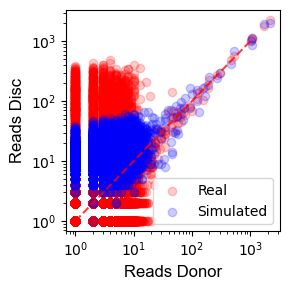

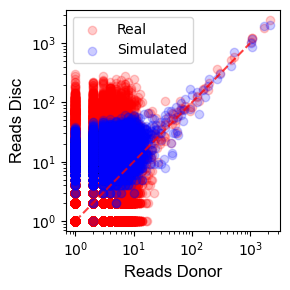

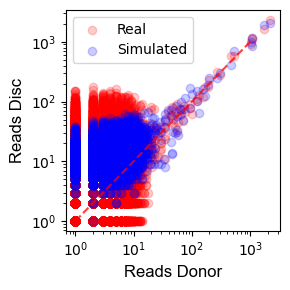

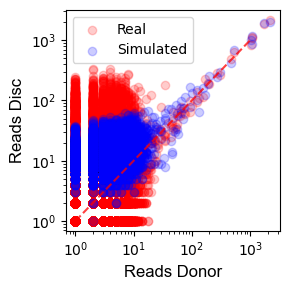

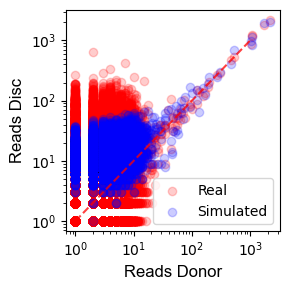

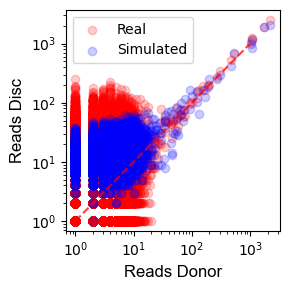

In [21]:
"""
Below we compare the distribution of the reads for the barcodes predicted by the model to the inoculum.
Then we compare it to the read data
"""

#Comparing the population to a simple bottleneck

for disc in ['12','13','14','15','16','17']:
    plt.figure(figsize = [3,3])
    plt.scatter(df_biofilm_filtered['3'],df_biofilm_filtered[disc], alpha = 0.2, color = 'red', label = 'Real', rasterized = True)
    plt.scatter(df_biofilm_filtered['3'],Sim_measured, alpha = 0.2, color = 'blue', label = 'Simulated', rasterized = True)
    
    plt.xscale('log')
    plt.yscale('log')
    
    plt.plot([1,10,100,1000],[1,10,100,1000], '--', color = 'red', alpha = 0.75)
    
    plt.xlabel('Reads Donor', fontname = 'arial', fontsize = 12)
    plt.ylabel('Reads Disc', fontname = 'arial', fontsize = 12)
    
    plt.legend()
    plt.tight_layout()
    
    plt.savefig('Figures paper/Simple model/Simple comparison_'+disc+'.svg', format = 'svg', dpi = 300)

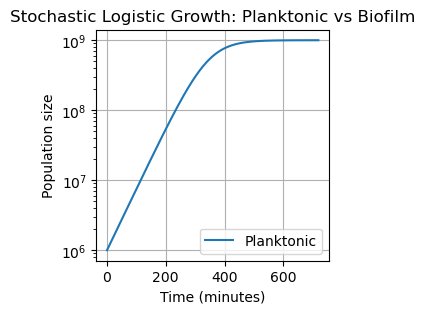

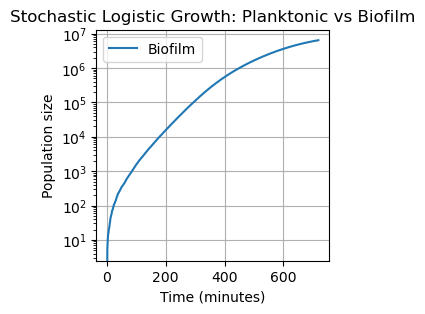

In [5]:
"""
The following is the model code that show the logistic equations used to describe binding and simulation

"""

import numpy as np
import matplotlib.pyplot as plt

Npo = 10**6  # Inoculum size
tdp = 34     # Doubling time planktonic
up = np.log(2)/tdp
dt = 1

N_p = [Npo]
N_d = [0]

tdd = 76
ud = np.log(2)/tdd
Ndmax = 10**7
kb = 10**(-5.45)
Npmax = 10**9

for i in range(1, 720):
    Nt = N_p[i-1]
    Ntd = N_d[i-1]
    
    # Planktonic growth
    expected_growth = up * Nt * (1 - Nt / Npmax)
    expected_growth = max(expected_growth, 0)
    delta_N = np.random.poisson(expected_growth)

    # Biofilm binding and growth
    expected_binding = max(Nt * kb * (1 - Ntd / Ndmax), 0)
    expected_growth_disc = ud * Ntd * (1 - Ntd / Ndmax)
    expected_growth_disc = max(expected_growth_disc, 0)
    
    delta_Nd = np.random.poisson(expected_binding) + np.random.poisson(expected_growth_disc)

    # Append updated populations
    N_p.append(Nt + delta_N)
    N_d.append(Ntd + delta_Nd)

# Plotting
plt.figure(figsize = [3,3])
plt.plot(range(720), N_p, label='Planktonic')
plt.xlabel('Time (minutes)')
plt.ylabel('Population size')
plt.title('Stochastic Logistic Growth: Planktonic vs Biofilm')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize = [3,3])
plt.plot(range(720), N_d, label='Biofilm')
plt.xlabel('Time (minutes)')
plt.ylabel('Population size')
plt.title('Stochastic Logistic Growth: Planktonic vs Biofilm')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()


In [87]:
"""Really really good code!!"""

import numpy as np
import pandas as pd
import os

# Setup
Npo = 4.3*10**7
Npmax = 10**10
Ndmax = 3.2*10**6
tdp = 34
up = np.log(2)/tdp
dt = 10
tdd_list = [70]  #doubling time disc

#We run the simulation for a range of binding constants
kb_list = 10**np.arange(-9,-5,0.005)

steps = int(1440/dt)
num_discs = 10

# Donor distribution
donor_f = df_biofilm_filtered['t_3_f']

Num_uniq_barcodes = []

discname_list = []
for i in range(10):
    discname_list.append('Disc_'+str(i))

df_founding_population = {}

for kb in kb_list:
    for tdd in tdd_list:
        um = np.log(2)/tdd
        # Initialize populations
        df_planktonic = np.random.multinomial(Npo, donor_f).astype(np.int32)
        df_discs = np.array([np.random.poisson(df_planktonic * kb) for _ in range(num_discs)])
        df_discs_binding = np.array([np.random.poisson(df_planktonic * kb) for _ in range(num_discs)])
        
        # Precompute capacity ratios to avoid repeated .sum()
        for t in range(steps):
            Np = df_planktonic.sum()
            #We estimate the carrying capacity in biofilms
            cap_p = max(1 - Np / Npmax, 0)
            if steps * 10 >= 60:
                #We model the growtn in the planktonic as a poisson (correct approx for small step size)
                growth_p = np.random.poisson(df_planktonic * up * cap_p * dt)
                df_planktonic += growth_p
        
            for d in range(num_discs):
                Nd = df_discs[d].sum()
                cap_d = max(1 - Nd / Ndmax, 0)
                #We model the growtn on the disc using poisson (correct approx for small step size)
                growth_d = np.random.poisson(df_discs[d] * um * cap_d * dt)
                #We model the growtn in the planktonic using a poisson distribution (correct approx for small step size)
                
                #We model the binding on disc using a poisson distribution (correct approx for small step size)
                binding = np.random.poisson(df_planktonic * kb * cap_d *dt)
                df_discs[d] += growth_d + binding
                df_discs_binding[d] += binding
        
        # Save once at the end
        if not os.path.exists('Simulation_final'):
            os.makedirs('Simulation_final')
        
        pd.concat([df_biofilm_filtered[['t_3_f']],pd.DataFrame(df_discs.transpose(), columns=discname_list,\
                                                       index=df_biofilm_filtered.index.values)], axis = 1)\
        .sort_values('t_3_f', ascending = 0).to_csv(f'Simulation_final/run_{round(np.log10(kb),3)}_{tdd}.csv', index=False)
        df_founding_population[round(np.log10(kb),3)] = df_discs_binding.sum()
        # Summary
        print(f"Completed simulation with kb={round(np.log10(kb),3)}, tdd={tdd}")
        print("Final unique barcodes per disc:", [np.sum(d > 0) for d in df_discs])
        Num_uniq_barcodes.append([np.sum(d > 0) for d in df_discs][0])

Completed simulation with kb=-9.0, tdd=70
Final unique barcodes per disc: [np.int64(7184), np.int64(7181), np.int64(7283), np.int64(7181), np.int64(7379), np.int64(7294), np.int64(7221), np.int64(7245), np.int64(7299), np.int64(7143)]
Completed simulation with kb=-8.995, tdd=70
Final unique barcodes per disc: [np.int64(7252), np.int64(7345), np.int64(7327), np.int64(7261), np.int64(7312), np.int64(7288), np.int64(7348), np.int64(7387), np.int64(7377), np.int64(7219)]
Completed simulation with kb=-8.99, tdd=70
Final unique barcodes per disc: [np.int64(7252), np.int64(7425), np.int64(7241), np.int64(7314), np.int64(7368), np.int64(7345), np.int64(7345), np.int64(7394), np.int64(7393), np.int64(7325)]
Completed simulation with kb=-8.985, tdd=70
Final unique barcodes per disc: [np.int64(7527), np.int64(7388), np.int64(7389), np.int64(7453), np.int64(7404), np.int64(7465), np.int64(7632), np.int64(7465), np.int64(7520), np.int64(7563)]
Completed simulation with kb=-8.98, tdd=70
Final unique

In [88]:
# Initialize an empty list to store bottleneck size results (not actually used later)
bottleneck_size = []

# Create two logarithmic ranges for kb values (rate constants, likely)
# kb_list1 covers a finer range from 10^-9 to 10^-6 in small steps (0.005 in log10 space)
kb_list1 = 10**np.arange(-9, -6, 0.005)
# kb_list2 covers a coarser range from 10^-6 to 10^-5 in larger steps (0.1 in log10 space)
kb_list2 = 10**np.arange(-6, -5, 0.1)

# Combine the two kb lists into one continuous array
kb_list = np.concatenate((kb_list1, kb_list2))

# Define the list of doubling times (Tdd values) to analyze
# Only one value (70) is used here
tdd_list = [70]

# Initialize empty DataFrames to store results:
# df_predict2 will hold the mean bottleneck estimates
# df_predictstd will hold the standard deviations of those estimates
df_predict2 = pd.DataFrame()
df_predictstd = pd.DataFrame()

# Initialize a list to store entropy estimates for each simulation
entropy_est = []

# Loop through each kb (rate constant)
for kb in kb_list:
    # Loop through each doubling time
    for tdd in tdd_list:
        
        # Load simulation results corresponding to the current kb and tdd values
        # The filename includes log10(kb) and tdd for identification
        df_predict = pd.read_csv(f'Simulation_final/run_{round(np.log10(kb),3)}_{tdd}.csv', index_col=0)
        
        # Optionally remove a column named 'Disc_0.1' if present (currently commented out)
        # df_predict = df_predict.drop('Disc_0.1', axis=1)
            
        # Initialize a list to store bottleneck estimates for this (kb, tdd)
        bottlneck_est = []
        
        # Perform 10 iterations to estimate bottleneck variability
        for i in range(0, 10):
            # Simulate a bottleneck event by drawing a multinomial sample
            # - 250,000 total trials
            # - probabilities proportional to df_predict['Disc_i']
            # This produces a simulated "post-bottleneck" distribution
            df_predict['Disc_' + str(i) + '_norm'] = np.random.multinomial(
                250000, df_predict['Disc_' + str(i)] / df_predict['Disc_' + str(i)].sum()
            )
            
            # Estimate the number of unique types (non-zero entries) after bottleneck
            bottlneck_est.append(len(df_predict.loc[df_predict['Disc_' + str(i) + '_norm'] > 0]))
            
        # Compute the average bottleneck size over 10 replicates
        score = np.mean(bottlneck_est)
        
        # Compute the standard deviation of bottleneck sizes
        score2 = np.std(bottlneck_est)
        
        # Compute entropy (Shannon diversity) for one of the normalized distributions
        # Measures how evenly distributed the population is after bottleneck
        entropy_est.append(entropy(df_predict.Disc_1_norm / df_predict.Disc_1_norm.sum(), base=2))
        
        # Store mean and std bottleneck size in corresponding DataFrames
        df_predict2.loc[round(np.log10(kb),3), tdd] = score
        df_predictstd.loc[round(np.log10(kb),3), tdd] = score2
        
        # Print progress to track which (kb, tdd) pair was processed
        print(round(np.log10(kb),3), tdd, score)


-9.0 70 4962.0
-8.995 70 5008.6
-8.99 70 5013.5
-8.985 70 5106.8
-8.98 70 5120.3
-8.975 70 5209.0
-8.97 70 5228.6
-8.965 70 5260.8
-8.96 70 5332.2
-8.955 70 5384.2
-8.95 70 5444.9
-8.945 70 5446.3
-8.94 70 5530.2
-8.935 70 5598.0
-8.93 70 5615.2
-8.925 70 5676.2
-8.92 70 5711.9
-8.915 70 5739.9
-8.91 70 5823.4
-8.905 70 5852.3
-8.9 70 5921.1
-8.895 70 5933.7
-8.89 70 6004.8
-8.885 70 6077.7
-8.88 70 6117.1
-8.875 70 6183.7
-8.87 70 6234.9
-8.865 70 6290.8
-8.86 70 6347.4
-8.855 70 6403.4
-8.85 70 6431.4
-8.845 70 6505.1
-8.84 70 6575.2
-8.835 70 6653.8
-8.83 70 6679.6
-8.825 70 6742.1
-8.82 70 6782.4
-8.815 70 6839.3
-8.81 70 6896.4
-8.805 70 6965.5
-8.8 70 7026.6
-8.795 70 7075.1
-8.79 70 7133.6
-8.785 70 7210.2
-8.78 70 7227.1
-8.775 70 7323.8
-8.77 70 7359.5
-8.765 70 7396.4
-8.76 70 7498.1
-8.755 70 7598.1
-8.75 70 7680.4
-8.745 70 7707.6
-8.74 70 7729.0
-8.735 70 7829.8
-8.73 70 7880.6
-8.725 70 7988.5
-8.72 70 8030.0
-8.715 70 8088.4
-8.71 70 8181.6
-8.705 70 8229.6
-8.7 70 8291.

In [89]:
#Save the generated figures
df_predict2.to_csv('Simulation_BC_Counts.csv')
df_predictstd.to_csv('Simulation_BC_Counts_std.csv')

In [7]:
"""Really really good code!!"""

import numpy as np
import pandas as pd
import os

# Setup
Npo = 4.3*10**7
Npmax = 10**10
Ndmax = 3.2*10**6
tdp = 34
up = np.log(2)/tdp
dt = 10
tdd_list = [70]  #doubling time disc

#We run the simulation for a range of binding constants
kb_list = [10**(-8.095)]

steps = int(1440/dt)
num_discs = 10

# Donor distribution
donor_f = df_biofilm_filtered['t_3_f']

Num_uniq_barcodes = []

discname_list = []
for i in range(10):
    discname_list.append('Disc_'+str(i))

df_founding_population = {}



for kb in kb_list:
    for tdd in tdd_list:
        um = np.log(2)/tdd
        # Initialize populations
        df_planktonic = np.random.multinomial(Npo, donor_f).astype(np.int32)
        df_discs = np.array([np.random.poisson(df_planktonic * kb) for _ in range(num_discs)])
        df_discs_binding = np.array([np.random.poisson(df_planktonic * kb) for _ in range(num_discs)])
        
        # Precompute capacity ratios to avoid repeated .sum()
        for t in range(steps):
            Np = df_planktonic.sum()
            #We estimate the carrying capacity in biofilms
            cap_p = max(1 - Np / Npmax, 0)
            if steps * 10 >= 60:
                #We model the growtn in the planktonic as a poisson (correct approx for small step size)
                growth_p = np.random.poisson(df_planktonic * up * cap_p * dt)
                df_planktonic += growth_p
        
            for d in range(num_discs):
                Nd = df_discs[d].sum()
                cap_d = max(1 - Nd / Ndmax, 0)
                #We model the growtn on the disc using poisson (correct approx for small step size)
                growth_d = np.random.poisson(df_discs[d] * um * cap_d * dt)
                #We model the growtn in the planktonic using a poisson distribution (correct approx for small step size)
                
                #We model the binding on disc using a poisson distribution (correct approx for small step size)
                binding = np.random.poisson(df_planktonic * kb * cap_d *dt)
                df_discs[d] += growth_d + binding
                df_discs_binding[d] += binding
        
        # Save once at the end
        if not os.path.exists('Simulation_final'):
            os.makedirs('Simulation_final')
        
        #pd.concat([df_biofilm_filtered[['t_3_f']],pd.DataFrame(df_discs.transpose(), columns=discname_list,\
        #                                               index=df_biofilm_filtered.index.values)], axis = 1)\
        #.sort_values('t_3_f', ascending = 0).to_csv(f'Simulation_final/run_{round(np.log10(kb),3)}_{tdd}.csv', index=False)
        df_founding_population[round(np.log10(kb),3)] = df_discs_binding.sum()
        # Summary
        print(f"Completed simulation with kb={round(np.log10(kb),3)}, tdd={tdd}")
        print("Final unique barcodes per disc:", [np.sum(d > 0) for d in df_discs])
        Num_uniq_barcodes.append([np.sum(d > 0) for d in df_discs][0])

Completed simulation with kb=-8.095, tdd=70
Final unique barcodes per disc: [np.int64(32092), np.int64(32388), np.int64(32418), np.int64(32231), np.int64(32615), np.int64(32129), np.int64(32189), np.int64(32284), np.int64(32072), np.int64(32289)]


In [6]:
#Getting the mean number of barcodes for the discs. Only the samples withh good read depth have been considered.

mean_disc = np.mean([21968,18835,21953,27549,28942,29329])
mean_disc = 20389
mean_disc

20389

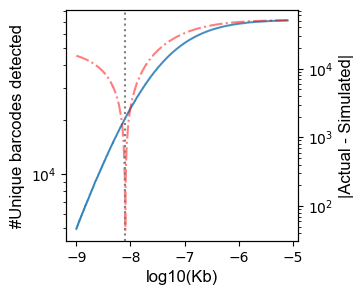

In [11]:
# Create two logarithmic ranges for kb values (rate constants, likely)
# kb_list1 covers a finer range from 10^-9 to 10^-6 in small steps (0.005 in log10 space)
kb_list1 = 10**np.arange(-9, -6, 0.005)
# kb_list2 covers a coarser range from 10^-6 to 10^-5 in larger steps (0.1 in log10 space)
kb_list2 = 10**np.arange(-6, -5, 0.1)

# Combine the two kb lists into one continuous array
kb_list = np.concatenate((kb_list1, kb_list2))

df_predict2 = pd.read_csv('Figurewise raw data/2B.Simulation_BC_Counts.csv', index_col=0)

df_predictstd = pd.read_csv('Figurewise raw data/2B.Simulation_BC_Counts_std.csv', index_col=0)

df = (df_predict2-mean_disc).abs()

#plot to plot the change in number of unique barcodes with Kd
fig,ax = plt.subplots(figsize=[3,3])
ax.plot(np.log10(kb_list),df_predict2, label = '#Barcodes', alpha = 0.75)
ax.fill_between(np.log10(kb_list),(df_predict2+1.96*df_predictstd)['70'],(df_predict2-1.96*df_predictstd)['70'], alpha = 0.75)
ax.set_ylabel('#Unique barcodes detected', fontname = 'Arial', fontsize = 12)

plt.yscale('log')

#plot to plot the change in number of unique barcodes in simulations versus ones detected in the experiment
ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.plot(np.log10(kb_list),df, '-.',color = 'red',label = '|Actual - Simulated|',alpha = 0.5)
plt.yscale('log')
ax2.set_ylabel('|Actual - Simulated|', fontname = 'Arial', fontsize = 12)
plt.axvline(x = -8.095, linestyle = ':', color = 'gray')

ax.set_xlabel('log10(Kb)', fontname = 'Arial', fontsize = 12)
plt.savefig('Figures paper/Simulation_Optimisation.svg', format = 'svg', dpi = 300)


In [8]:
df = (df_predict2-mean_disc).abs()
df.loc[df['70'] == min(df['70'])]

,70
-8.095,44.1


In [ ]:
from scipy.stats import gaussian_kde

plt.figure(figsize=(3, 3))
df_plot = df_biofilm_filtered[(df_biofilm_filtered[['3','13']] > 0).all(axis = 1)][['3','13']]
#plt.scatter(df_biofilm_filtered['3'], df_biofilm_filtered['13'], color = 'blue', alpha = 0.2, label = 'actual', rasterized = True)

x = df_biofilm_filtered['3']
y = df_biofilm_filtered['13']

import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    x=x, 
    y=y,
    cmap="mako",
    fill=True,
    thresh=0,
    levels=50
)
plt.xlabel("Experiment 1 counts")
plt.ylabel("Experiment 2 counts")
plt.title("2D KDE Density Plot")
plt.show()

In [12]:
df_predict = pd.read_csv(f'Simulation_final/run_-8.095_70.csv')
df_predict.to_csv('Figurewise raw data/2C-2F Optimum Simulation_run_-8.095_70.csv')

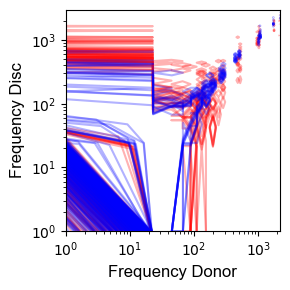

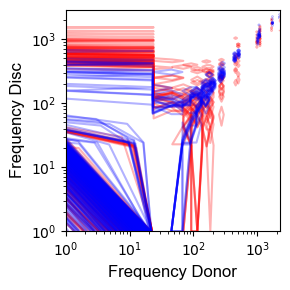

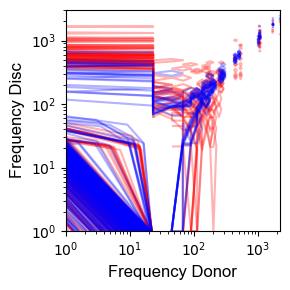

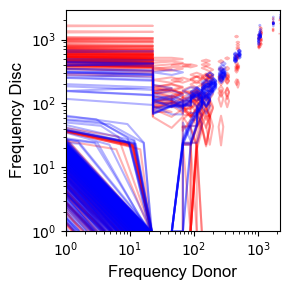

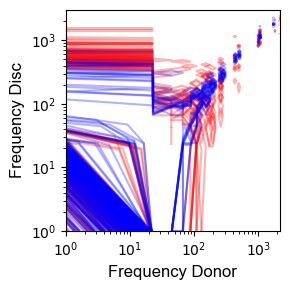

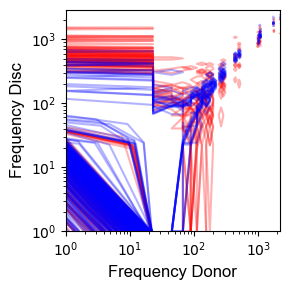

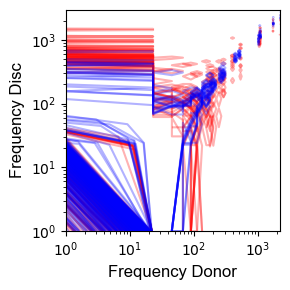

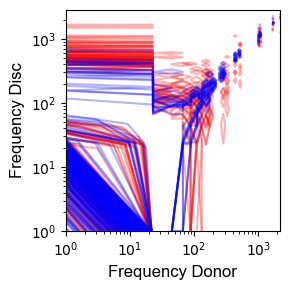

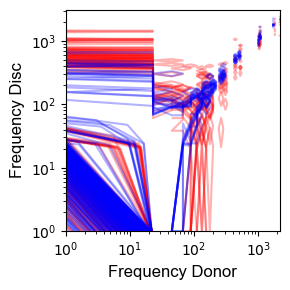

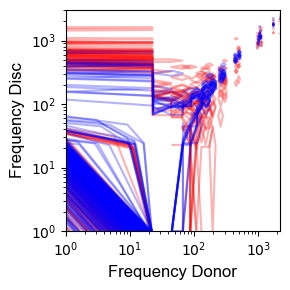

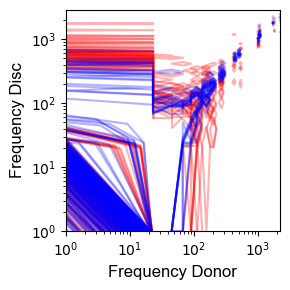

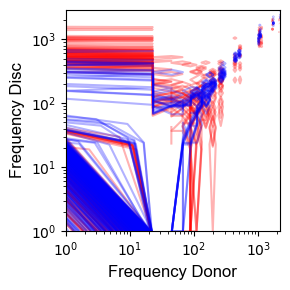

In [14]:
df_predict = pd.read_csv(f'Simulation_final/run_-8.095_70.csv')
df_predict.to_csv('Figurewise raw data/2C-2F Optimum Simulation_run_-8.095_70.csv')

#df_predict = df_predict.drop('Disc_0.1', axis = 1)

discs = ['12','13','14','15','16','17','18','19','20','21','22','23']
counts = [550972,201846,91586,169592,155159,247703,426214,49342,105549,350283,146521,611665]
for n in range(0,12):
    df_predict['Donor_norm'] = np.random.multinomial(250000,df_predict.t_3_f)
    for i in range(0,10):
        df_predict['Disc_'+str(i)+'_sample'] = np.random.multinomial(counts[n],df_predict['Disc_'+str(i)]/df_predict['Disc_'+str(i)].sum())
        df_predict['Disc_'+str(i)+'_norm'] = np.random.multinomial(250000,df_predict['Disc_'+str(i)+'_sample']/df_predict['Disc_'+str(i)+'_sample'].sum())
        df_predict['Disc_'+str(i)+'_enrichment'] = ((df_predict['Disc_'+str(i)+'_norm']+0.5)/(df_predict.Donor_norm+0.5)).apply(np.log10)
    
    
    plt.figure(figsize=(3, 3))
    for i in range(0,10):
        discname = 'Disc_'+str(i)+'_norm'
        df_plot = df_predict[(df_predict[['Donor_norm',discname]] > 0).all(axis = 1)][['Donor_norm',discname]]
        # Assuming x = donor frequency, y = biofilm frequency
        x = df_plot['Donor_norm']
        y = df_plot[discname]
        
        # 2D histogram
        H_sim, xedges, yedges = np.histogram2d(x, y, bins=100)
        X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
        plt.contour(X, Y, H_sim.T, levels=20, colors='red', alpha = 0.3)
        
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Frequency Donor', fontname = 'Arial', fontsize = 12)
    plt.ylabel('Frequency Disc', fontname = 'Arial', fontsize = 12)
    
    for disc in ['12','13','14','15','16','17','18','19','20','21','22','23']:
        df_plot = df_biofilm_filtered[(df_biofilm_filtered[['3',disc]] > 0).all(axis = 1)][['3',disc]]
        
        # Assuming x = donor frequency, y = biofilm frequency
        x = df_plot['3']
        y = df_plot[disc]
        
        # 2D histogram
        H_real, xedges, yedges = np.histogram2d(x, y, bins=100)
        
        X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
        plt.contour(X, Y, H_real.T, levels=20, colors='blue', alpha = 0.3)
        
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Frequency Donor', fontname = 'Arial', fontsize = 12)
    plt.ylabel('Frequency Disc', fontname = 'Arial', fontsize = 12)
    plt.tight_layout()
    plt.savefig('Figures paper/Simulation/Simulation_Real_density_'+str(discs[n])+'.svg', format = 'svg', dpi = 300)
    
    for i in range(0,10):
        plt.figure(figsize=(3, 3))
    
        df_plot = df_predict
        plt.scatter(df_plot['Donor_norm'], df_plot['Disc_'+str(i)+'_norm'], color = 'red', alpha = 0.2, label = 'simulated', rasterized = True)
        plt.yscale('log')
        plt.xscale('log')
        
        df_plot = df_biofilm_filtered
        #.loc[df_actual['3_norm'] > 1]
        plt.scatter(df_biofilm_filtered['3'], df_biofilm_filtered[discs[n]], color = 'blue', alpha = 0.2, label = 'actual', rasterized = True)
        plt.yscale('log')
        plt.xscale('log')
        #plt.legend()
        
        plt.xlabel('Frequency Donor', fontname = 'Arial', fontsize = 12)
        plt.ylabel('Frequency Disc', fontname = 'Arial', fontsize = 12)
        plt.tight_layout()
        plt.savefig('Figures paper/Simulation/Simulation_Real_comparison_'+str(discs[n])+'_'+str(i)+'.svg', format = 'svg', dpi = 300)
        plt.close()

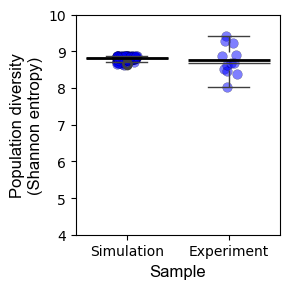

In [14]:
#Code to compare the Shannon entropy between simulation and experiment

from scipy.stats import entropy
from scipy.spatial import distance

df_predict = pd.read_csv(f'Simulation_final/run_-8.095_70.csv')

df_predict['Donor_norm'] = np.random.multinomial(250000,df_predict.t_3_f)

shannon = []

for n in [550972,201846,91586,169592,155159,247703,426214,49342,105549,350283,146521,611665]:
    for i in range(0,10):
        df_predict['Disc_'+str(i)+'_sample'] = np.random.multinomial(n,df_predict['Disc_'+str(i)]/df_predict['Disc_'+str(i)].sum())
        df_predict['Disc_'+str(i)+'_norm'] = np.random.multinomial(250000,df_predict['Disc_'+str(i)+'_sample']/df_predict['Disc_'+str(i)+'_sample'].sum())
        df_predict['Disc_'+str(i)+'_enrichment'] = ((df_predict['Disc_'+str(i)+'_norm']+0.5)/(df_predict.Donor_norm+0.5)).apply(np.log10)
    for i in range(0,10):
        shannon.append(entropy(df_predict['Disc_'+str(i)+'_norm']/df_predict['Disc_'+str(i)+'_norm'].sum()))

df_shannon = pd.DataFrame(shannon).rename(columns = {0:'Shannon Entropy'})
df_shannon['Source'] = 'Simulation'

df_experiment = pd.read_csv('Figurewise raw data/1D1E.Shannon-Bray Curtis from inoculum.csv', index_col=0)
df  = df_experiment.loc[df_experiment.Sample == 'Disc'][['Shannon Entropy']]
df['Source'] = 'Experiment'
df_shannon= pd.concat([df_shannon,df])

plt.figure(figsize = [3,3])

#Construct a box plot to show median and variance in the population
sns.boxplot(data=df_shannon, x="Source", y="Shannon Entropy", showmeans = True, meanline = True,\
            medianprops = {'visible':True}, whiskerprops={'visible':True},zorder = 10, showfliers = True, showbox = False,\
           showcaps = True, meanprops = {'color': 'k', 'ls':'-','lw':2})

sns.stripplot(data=df_shannon, x="Source", y="Shannon Entropy", s=7, edgecolor='black', color = 'blue', linewidth=0.25, alpha = 0.5, legend = False)

plt.ylim([4,10])
plt.xlabel('Sample', fontname = 'Arial', fontsize = 12)
plt.ylabel('Population diversity\n(Shannon entropy)', fontname = 'arial', fontsize = 12)
plt.tight_layout()

df_shannon.to_csv('Figurewise raw data/2D.SimulationvExp_Shannon.csv')

plt.savefig('Figures paper/Simulation_Real_Shannon.svg', format = 'svg', dpi = 300)

In [15]:
from scipy import stats

exp_values = df_shannon.loc[df_shannon.Source == 'Experiment', 'Shannon Entropy']
sim_values = df_shannon.loc[df_shannon.Source == 'Simulation', 'Shannon Entropy']

ks_stat, ks_pval = stats.ks_2samp(exp_values, sim_values)
print(f"KS statistic = {ks_stat:.4f}, p = {ks_pval:.4g}")

KS statistic = 0.5250, p = 0.002825


In [16]:
# Try exact if available
try:
    u_stat, p_exact = stats.mannwhitneyu(exp_values, sim_values, alternative='two-sided', method='asymptotic')
    print("Mann-Whitney (exact):", u_stat, p_exact)
except TypeError:
    # fallback to permutation
    from itertools import combinations
    # or do permutation similar to KS above


Mann-Whitney (exact): 597.0 0.3322158116933951


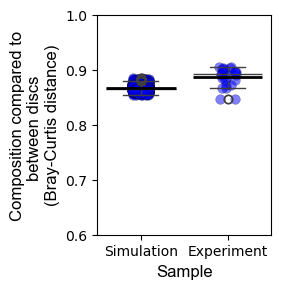

In [17]:
#Code to compare the Bray-curtis distance from the inoculum between simulation and experiment

from scipy.stats import entropy
from scipy.spatial import distance

df_predict = pd.read_csv(f'Simulation_final/run_-8.095_70.csv')

df_predict['Donor_norm'] = np.random.multinomial(250000,df_predict.t_3_f)

bray_curtis = []

for n in [550972,201846,91586,169592,155159,247703,426214,49342,105549,350283,146521,611665]:
    for i in range(0,10):
        df_predict['Disc_'+str(i)+'_sample'] = np.random.multinomial(n,df_predict['Disc_'+str(i)]/df_predict['Disc_'+str(i)].sum())
        df_predict['Disc_'+str(i)+'_norm'] = np.random.multinomial(250000,df_predict['Disc_'+str(i)+'_sample']/df_predict['Disc_'+str(i)+'_sample'].sum())
        df_predict['Disc_'+str(i)+'_enrichment'] = ((df_predict['Disc_'+str(i)+'_norm']+0.5)/(df_predict.Donor_norm+0.5)).apply(np.log10)
    for i in range(0,10):
        for j in range(0,10):
            if i != j:
                bray_curtis.append((distance.braycurtis(df_predict['Disc_'+str(i)+'_norm']/df_predict['Disc_'+str(i)+'_norm'].sum(),\
                    df_predict['Disc_'+str(j)+'_norm']/df_predict['Disc_'+str(j)+'_norm'].sum())))

df_distance = pd.DataFrame(bray_curtis).rename(columns = {0:'Distance'})
df_distance['Sample'] = 'Simulation'

df_experiment = pd.read_csv('Figurewise raw data/1G.Bray Curtis between discs.csv', index_col=0)
df_experiment = df_experiment.loc[df_experiment.Sample == 'Disc\n(Intra-well)'][['Distance']]
df_experiment['Sample'] = 'Experiment'
df_distance = pd.concat([df_distance,df_experiment])

df_distance.to_csv('Figurewise raw data/2E.SimulationvExp_Distance.csv')

plt.figure(figsize = [3,3])

#Construct a box plot to show median and variance in the population
sns.boxplot(data=df_distance, x="Sample", y="Distance", showmeans = True, meanline = True,\
            medianprops = {'visible':True}, whiskerprops={'visible':True},zorder = 10, showfliers = True, showbox = False,\
           showcaps = True, meanprops = {'color': 'k', 'ls':'-','lw':2})

sns.stripplot(data=df_distance, x="Sample", y="Distance", s=7, edgecolor='black', color = 'blue', linewidth=0.25, alpha = 0.5, legend = False)

plt.ylim([0.6,1])
plt.xlabel('Sample', fontname = 'Arial', fontsize = 12)
plt.ylabel('Composition compared to\nbetween discs \n(Bray-Curtis distance)', fontname = 'arial', fontsize = 12)
plt.tight_layout()
plt.savefig('Figures paper/Simulation_Real_Bray_Curtis.svg', format = 'svg', dpi = 300)

In [18]:
from scipy import stats

exp_values = df_distance.loc[df_distance.Sample == 'Experiment', 'Distance']
sim_values = df_distance.loc[df_distance.Sample == 'Simulation', 'Distance']

ks_stat, ks_pval = stats.ks_2samp(exp_values, sim_values)
print(f"KS statistic = {ks_stat:.4f}, p = {ks_pval:.4g}")

KS statistic = 0.7333, p = 2.355e-13


In [19]:
# Try exact if available
try:
    u_stat, p_exact = stats.mannwhitneyu(exp_values, sim_values, alternative='two-sided', method='asymptotic')
    print("Mann-Whitney (exact):", u_stat, p_exact)
except TypeError:
    # fallback to permutation
    from itertools import combinations
    # or do permutation similar to KS above


Mann-Whitney (exact): 22416.0 9.336331471358906e-10


In [20]:
from scipy.stats import entropy
from scipy.spatial import distance

df_predict = pd.read_csv(f'Simulation_final/run_-8.095_70.csv')

df_predict['Donor_norm'] = np.random.multinomial(250000,df_predict.t_3_f)
for i in range(0,10):
    df_predict['Disc_'+str(i)+'_sample'] = np.random.multinomial(250000,df_predict['Disc_'+str(i)]/df_predict['Disc_'+str(i)].sum())
    df_predict['Disc_'+str(i)+'_norm'] = np.random.multinomial(250000,df_predict['Disc_'+str(i)+'_sample']/df_predict['Disc_'+str(i)+'_sample'].sum())
    df_predict['Disc_'+str(i)+'_f'] = df_predict['Disc_'+str(i)+'_norm']/df_predict['Disc_'+str(i)+'_norm'].sum()
    df_predict['Disc_'+str(i)+'_enrichment'] = ((df_predict['Disc_'+str(i)+'_norm']+0.5)/(df_predict.Donor_norm+0.5)).apply(np.log10)

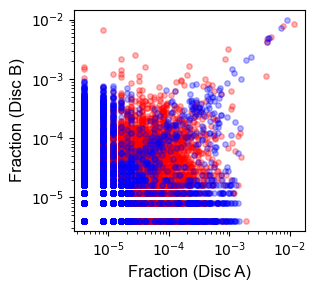

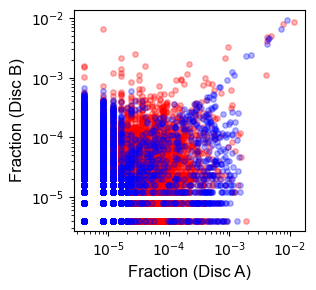

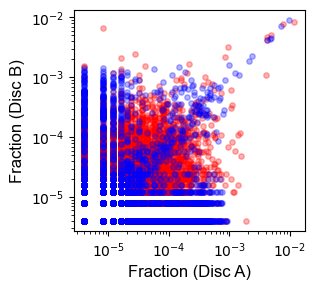

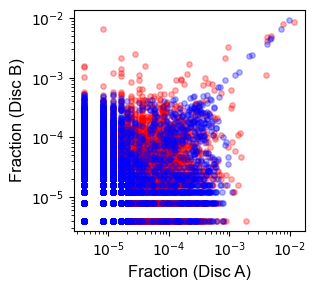

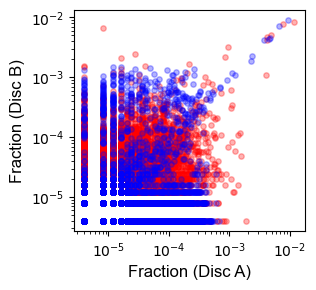

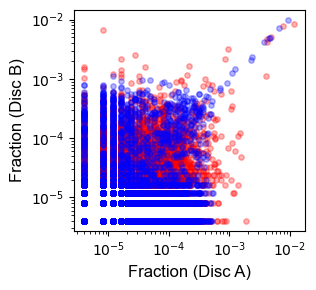

In [21]:
#Code to compare the trends in the distribution of barcodes between two discs
#for the experiment versus the simulation.= for replicate A

Disc_A = ['12','13','14']
Disc_B = ['12','13','14']

for i in range(0, len(Disc_A)):
    for j in range(0, len(Disc_A)):
        if Disc_A[i] != Disc_B[j]:
            df_plot = df_biofilm_filtered#.loc[(df_biofilm_filtered[Disc_A[i]] > 0) & (df_biofilm_filtered[Disc_B[j]] > 0)]
            
            #plot the correlation between the frequencies between the two discs
            plt.figure(figsize=[3.25,3])
            
            plt.scatter(df_predict['Disc_0_f'],df_predict['Disc_1_f'], s = 15, alpha = 0.3, rasterized = True, color = 'red')
            
            plt.scatter(df_plot['t_'+Disc_A[i]+'_f'],df_plot['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, rasterized = True, color = 'blue')

            
            plt.xscale('log')
            plt.yscale('log')

            plt.xlabel('Fraction (Disc A)', fontname = 'Arial', fontsize = 12)
            plt.ylabel('Fraction (Disc B)', fontname = 'Arial', fontsize = 12)
            
            plt.tight_layout()
            plt.savefig('Figures paper/Simulation_DD/Correlation Disc Disc '+ Disc_A[i] + Disc_B[j] +'.svg', format = 'svg', dpi = 300)
            

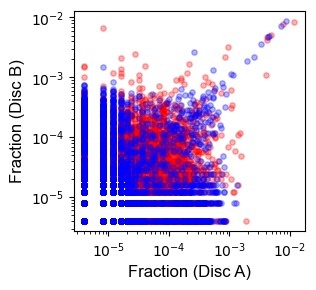

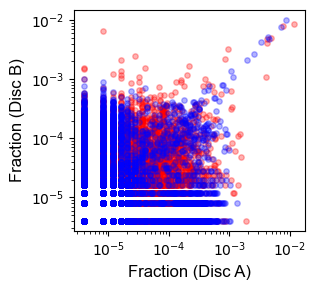

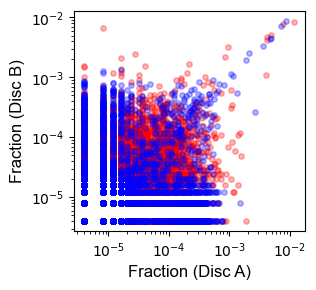

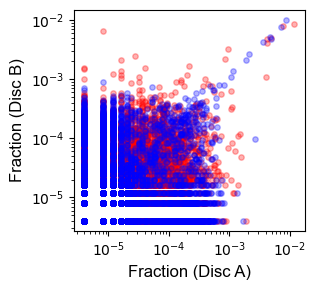

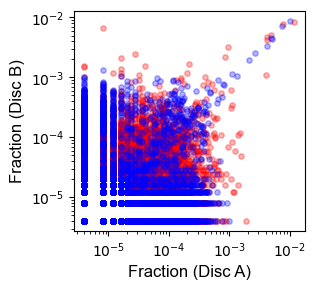

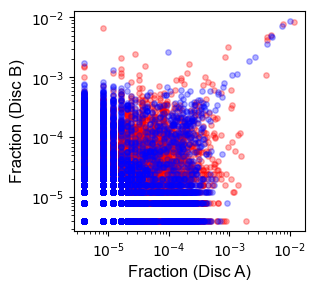

In [22]:
#Code to compare the trends in the distribution of barcodes between two discs
#for the experiment versus the simulation.= for replicate B

Disc_A = ['15','16','17']
Disc_B = ['15','16','17']

for i in range(0, len(Disc_A)):
    for j in range(0, len(Disc_A)):
        if Disc_A[i] != Disc_B[j]:
            df_plot = df_biofilm_filtered#.loc[(df_biofilm_filtered[Disc_A[i]] > 0) & (df_biofilm_filtered[Disc_B[j]] > 0)]
            
            #plot the correlation between the frequencies between the two discs
            plt.figure(figsize=[3.25,3])
            
            plt.scatter(df_predict['Disc_0_f'],df_predict['Disc_1_f'], s = 15, alpha = 0.3, rasterized = True, color = 'red')
            
            plt.scatter(df_plot['t_'+Disc_A[i]+'_f'],df_plot['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, rasterized = True, color = 'blue')

            
            plt.xscale('log')
            plt.yscale('log')

            plt.xlabel('Fraction (Disc A)', fontname = 'Arial', fontsize = 12)
            plt.ylabel('Fraction (Disc B)', fontname = 'Arial', fontsize = 12)
            
            plt.tight_layout()
            plt.savefig('Figures paper/Simulation_DD/Correlation Disc Disc '+ Disc_A[i] + Disc_B[j] +'.svg', format = 'svg', dpi = 300)
            

In [23]:
df_predict['Disc_0_f'] = df_predict.Disc_0/df_predict.Disc_0.sum()
df_predict['Disc_1_f'] = df_predict.Disc_1/df_predict.Disc_1.sum()

df_predict.loc[(df_predict.Disc_0_enrichment > 0.8) & (df_predict.Disc_1_enrichment > 0.8)].Disc_0_f.sum()
df_predict.loc[(df_predict.Disc_0_enrichment > 0.8) & (df_predict.Disc_1_enrichment > 0.8)].Disc_0_f.sum()


np.float64(0.027110452533364)

In [24]:
import numpy as np
import pandas as pd

# Compute enrichment threshold
cols = [f"t_{i}_enrichment" for i in range(8, 12)]
enrichment_values = [
    df_biofilm_filtered[col].mean() + 1.96 * df_biofilm_filtered[col].std()
    for col in cols
]
enrichment_threshold = np.mean(enrichment_values) + 1.96 * np.std(enrichment_values)
enrichment_threshold

np.float64(0.6360058016531004)

In [25]:
records = []
for n in [550972,201846,91586,169592,155159,247703,426214,49342,105549,350283,146521,611665]:
    for i in range(0,10):
        df_predict['Disc_'+str(i)+'_sample'] = np.random.multinomial(n,df_predict['Disc_'+str(i)]/df_predict['Disc_'+str(i)].sum())
        df_predict['Disc_'+str(i)+'_norm'] = np.random.multinomial(250000,df_predict['Disc_'+str(i)+'_sample']/df_predict['Disc_'+str(i)+'_sample'].sum())
        df_predict['Disc_'+str(i)+'_f'] = df_predict['Disc_'+str(i)+'_norm']/df_predict['Disc_'+str(i)+'_norm'].sum()
        df_predict['Disc_'+str(i)+'_enrichment'] = ((df_predict['Disc_'+str(i)+'_norm']+0.5)/(df_predict.Donor_norm+0.5)).apply(np.log10)
    
    for d1 in range(0,10):
        for d2 in range(0,10):
            if d1 != d2:
                mask = (
                    (df_predict['Disc_'+str(d1)+'_enrichment'] >= enrichment_threshold) &
                    (df_predict['Disc_'+str(d2)+'_enrichment'] >= enrichment_threshold)
                )
                df1 = df_predict.loc[mask]
                for disc in (d1, d2):
                    records.append({
                        'Sample': 'Simulation',
                        'Replicate': 'E',
                        'Fraction': df1['Disc_'+str(d1)+'_f'].sum()
                    })


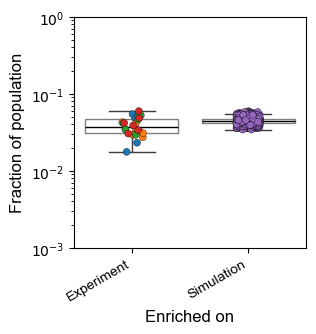

In [26]:
#Code to compare the trends in the dfraction of population uniquely enriched on a single disc

df_samples = pd.read_excel('Figurewise raw data/1I. Disc_fraction_prbability.xlsx', index_col=0)
df_samples_sim = pd.DataFrame(records)
df_compare = pd.concat([df_samples.loc[df_samples.Sample == 'Two disc\nsame well'],df_samples_sim], axis = 0)
df_compare.loc[df_compare.Sample == 'Two disc\nsame well', 'Sample'] = 'Experiment'

df_probability_enrichment = df_samples
plt.figure(figsize = [3,3])
sns.stripplot(data=df_compare, x="Sample", y="Fraction", hue = 'Replicate', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='Sample', y='Fraction', data=df_compare,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))

plt.xticks(rotation = 30, ha = 'right', fontname = 'arial', fontsize = 10)
plt.xticks(fontname = 'arial', fontsize = 10)


df_probability_enrichment.to_csv('Figurewise raw data/2G.SimulationvExp_Fraction.csv')

plt.yscale('log')
plt.ylim([0.001,1])
plt.xlabel('Enriched on', fontname = 'Arial', fontsize = 12)
plt.ylabel('Fraction of population', fontname = 'Arial', fontsize = 12)
plt.savefig('Figures paper/Simulation_Real_fraction.svg', format = 'svg', dpi = 300)


In [27]:
discs = ['12','13','14','15','16','17','18','19','20','21','22','23']
Ne_actual = []

#Calculation of the actual population size
for disc in discs:
    Ne_actual.append(1/sum(df_biofilm_filtered['t_'+disc+'_f']**2))

np.mean(Ne_actual),np.std(Ne_actual)

(np.float64(2332.480669470312), np.float64(570.675175888375))

0


C:\Users\achoudhu\AppData\Local\Temp\ipykernel_308\3572162703.py:61: RuntimeWarning: invalid value encountered in divide
  pi = p/np.sum(p)


[np.float64(0.0036868349438623363)]
1


C:\Users\achoudhu\AppData\Local\Temp\ipykernel_308\3572162703.py:61: RuntimeWarning: invalid value encountered in divide
  pi = p/np.sum(p)


[np.float64(0.0036868349438623363), np.float64(0.0034530334790981304)]
2


...

[np.float64(0.0036868349438623363), np.float64(0.0034530334790981304), np.float64(0.005226589482703023), np.float64(0.004436387024461249), np.float64(0.004119208851159421), np.float64(0.010305353199482194), np.float64(0.0070011913653749295), np.float64(0.004601862869187073)]
8


C:\Users\achoudhu\AppData\Local\Temp\ipykernel_308\3572162703.py:61: RuntimeWarning: invalid value encountered in divide
  pi = p/np.sum(p)


[np.float64(0.0036868349438623363), np.float64(0.0034530334790981304), np.float64(0.005226589482703023), np.float64(0.004436387024461249), np.float64(0.004119208851159421), np.float64(0.010305353199482194), np.float64(0.0070011913653749295), np.float64(0.004601862869187073), np.float64(0.004380213709789917)]
9


C:\Users\achoudhu\AppData\Local\Temp\ipykernel_308\3572162703.py:61: RuntimeWarning: invalid value encountered in divide
  pi = p/np.sum(p)


[np.float64(0.0036868349438623363), np.float64(0.0034530334790981304), np.float64(0.005226589482703023), np.float64(0.004436387024461249), np.float64(0.004119208851159421), np.float64(0.010305353199482194), np.float64(0.0070011913653749295), np.float64(0.004601862869187073), np.float64(0.004380213709789917), np.float64(0.005405772946882609)]


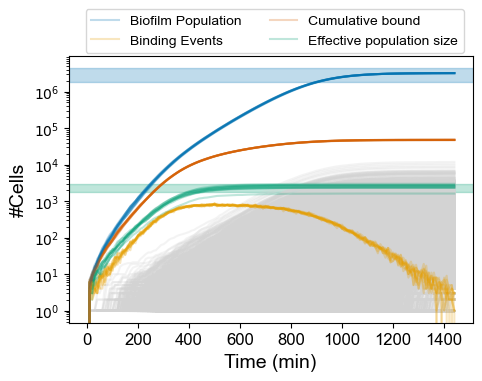

In [28]:
"""Really really good code!!"""

import numpy as np
import pandas as pd
import os

# Setup
Npo = 4.3*10**7
Npmax = 10**10
Ndmax = 3.2*10**6

tdp = 34 #Doubling time in the planktonic phase
up = np.log(2)/tdp #Growth rate in the planktonic phase
dt = 10
tdd = 70  #doubling time disc

#We run the simulation for the best binding constant
kb = 10**(-8.095)

steps = int(1440/dt)

um = np.log(2)/tdd #Growth rate on the disc

ind_binding = []

df_simulation = []

percent_pop = []

plt.figure(figsize = [5,4])

#We run 10 simulations at the optimum values for Kd to understand lineage dynamics
for i in range(0,10):
    print(i)
    growth_p = [Npo]
    df_discs = [np.array([0])]

    #initialize the array for binding events
    binding_events = [0]

    #Initialize the array for total number of binding events
    binding_total = [0]

    #Inititalize the array for total effective population size
    Ne_total = [0]
    
    for t in range(steps):
        cap_p = max(1 - growth_p[t] / Npmax, 0) #Growth cap in planotnic
        growth = np.random.poisson(growth_p[t] * up * cap_p * dt) #number of growth events in the planktonic phase
        growth_p.append(growth_p[t]+growth) #Update the planktonic phase
    
        cap_d = max(1 - sum(df_discs[t]) / Ndmax, 0) #Growth cap on disc
        binding = np.random.poisson(growth_p[t] * kb * cap_d *dt) #Number of binding events on disc
        growth_d = np.random.poisson(np.random.poisson(df_discs[t] * um * cap_d * dt)) #Growth on discs
        
        binding_events.append(binding) #update number of Binding events
        binding_total.append(binding_total[t] + binding) #Update total binding
        
        df_discs.append(np.concatenate((df_discs[t]+growth_d, np.ones(binding)))) #Update the disc dataframe with growth and binding
        p = df_discs[t]+growth_d 
        pi = p/np.sum(p)
        Ne = 1/np.sum(pi**2) #Calculate effective population size
        Ne_total.append(Ne) #Update effective population size code
        
    df_binding = pd.DataFrame(df_discs).transpose()
    
    #plt.plot(np.arange(0,1450,10),growth_p)

    if i == 0:
        plt.plot(np.arange(0,1450,10), df_binding.transpose(), color = 'lightgray', alpha = 0.25, rasterized=True);
    
    plt.plot(np.arange(0,1450,10),df_binding.sort_values(144).sum(), color = '#0072B2', alpha = 0.25, label = '')
    
    plt.plot(np.arange(0,1450,10),binding_events, color = '#E69F00',alpha = 0.25, label = '')
    
    plt.plot(np.arange(0,1450,10),binding_total, color = '#D55E00',alpha = 0.25, label = '')

    plt.plot(np.arange(0,1450,10),Ne_total, color = '#009E73',alpha = 0.25, label = '')
    
    plt.yscale('log')
    df_simulation.append(df_discs)
    
    ind_binding.append(binding_total[t])

    percent_pop.append(max(df_discs[144])/sum(df_discs[144]))
    print(percent_pop)

plt.plot(np.arange(0,1450,10),df_binding.sort_values(144).sum(), color = '#0072B2', alpha = 0.25, label = 'Biofilm Population', rasterized=True)
    
plt.plot(np.arange(0,1450,10),binding_events, color = '#E69F00', alpha = 0.25, label = 'Binding Events')
    
plt.plot(np.arange(0,1450,10),binding_total, color = '#D55E00', alpha = 0.25, label = 'Cumulative bound')

plt.plot(np.arange(0,1450,10),Ne_total, color = '#009E73', alpha = 0.25, label = 'Effective population size')

# Highlight the variance in the actual data
plt.axhspan(
    np.mean(Ne_actual) - np.std(Ne_actual),
    np.mean(Ne_actual) + np.std(Ne_actual),
    color='#009E73', alpha=0.25
)

plt.axhspan(
    3.16*10**(6) - 1.30*10**(6),
    3.16*10**(6) + 1.30*10**(6),
    color='#0072B2', alpha=0.25
)

plt.legend(
    loc='upper left',
    prop={'family': 'Arial', 'size': 10},
    ncol = 2,
    bbox_to_anchor = [0.025, 1.2]
)

plt.xticks(fontname = 'arial', fontsize = 12)
plt.xticks(fontname = 'arial', fontsize = 12)
plt.xlabel('Time (min)', fontname = 'arial', fontsize = 14)
plt.ylabel('#Cells', fontname = 'arial', fontsize = 14)

plt.tight_layout()

plt.savefig('Figures paper/2H.Temporal Simulation summary.png', format = 'png', dpi = 300)
plt.savefig('Figures paper/2H.Temporal Simulation summary.svg', format = 'svg', dpi = 300)


In [39]:
pd.DataFrame([binding_events, binding_total, Ne_total]).transpose().\
rename(columns = {0:'Binding events', 1: 'Total binding', 2:'Effective pop. size'}).to_csv('Figurewise raw data/2H. binding events')


In [40]:
##### Extract the final state of lineages from a simulation run
final_lineages = df_discs[-1]

# You need to know WHEN each lineage was created. 
# We can track this by storing the 'birth_step' for every element in df_discs.
birth_times = []
for t, num_new_binders in enumerate(binding_events):
    birth_times.extend([t * dt] * num_new_binders)

# Match birth times to final lineage sizes
# Note: df_discs[0] had an initial '0' which we should ignore or handle
expansion_data = pd.DataFrame({
    'BirthTime': birth_times,
    'FinalSize': final_lineages[1:] # Exclude the initial 0-placeholder if necessary
})

# Assuming 'final_sizes' is an array of the counts of each lineage
final_sizes = df_discs[-1]

# 1. Calculate frequencies (pi)
total_population = np.sum(final_sizes)
p_i = final_sizes / total_population

# 2. Calculate Ne
effective_size = 1 / np.sum(p_i**2)

print(f"Total Cells (N): {total_population}")
print(f"Effective Population Size (Ne): {effective_size:.2f}")

Total Cells (N): 3191403.0
Effective Population Size (Ne): 2337.77


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


<Figure size 550x400 with 0 Axes>

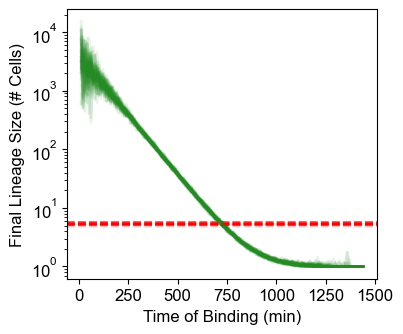

In [41]:
"""Really really good code!!"""

import numpy as np
import pandas as pd
import os

# Setup
Npo = 4.3*10**7
Npmax = 10**10
Ndmax = 3.2*10**6

tdp = 34
up = np.log(2)/tdp
dt = 10
tdd = 70  #doubling time disc

#We run the simulation for a range of binding constants
kb = 10**(-8.095)

steps = int(1440/dt)

um = np.log(2)/tdd

ind_binding = []

df_simulation = []

percent_pop = []

plt.figure(figsize = [5.5,4])

plt.figure(figsize=(4, 3.5))

for i in range(0,50):
    print(i)
    growth_p = [Npo]
    df_discs = [np.array([0])]
    binding_events = [0]
    binding_total = [0]
    for t in range(steps):
        cap_p = max(1 - growth_p[t] / Npmax, 0)
        growth = np.random.poisson(growth_p[t] * up * cap_p * dt)
        growth_p.append(growth_p[t]+growth)
    
        cap_d = max(1 - sum(df_discs[t]) / Ndmax, 0)
        binding = np.random.poisson(growth_p[t] * kb * cap_d *dt)
        growth_d = np.random.poisson(np.random.poisson(df_discs[t] * um * cap_d * dt))
        
        binding_events.append(binding)
        binding_total.append(binding_total[t] + binding)
        
        df_discs.append(np.concatenate((df_discs[t]+growth_d, np.ones(binding))))
        
    df_binding = pd.DataFrame(df_discs).transpose()
    
    # 1. Define the time axis based on your simulation parameters
    # We use len(df_discs) to ensure it matches the data exactly
    time_axis = np.linspace(0, steps * dt, len(df_discs))
    
    ne_history = []
    n_total_history = []
    
    for step_sizes in df_discs:
        total = np.sum(step_sizes)
        if total > 0:
            p_i = step_sizes / total
            ne = 1 / np.sum(p_i**2)
            ne_history.append(ne)
            n_total_history.append(total)
        else:
            ne_history.append(0)
            n_total_history.append(0)
    
    # Extract the final state of lineages from a simulation run
    final_lineages = df_discs[-1]
    
    # You need to know WHEN each lineage was created. 
    # We can track this by storing the 'birth_step' for every element in df_discs.
    birth_times = []
    for t, num_new_binders in enumerate(binding_events):
        birth_times.extend([t * dt] * num_new_binders)
    
    # Match birth times to final lineage sizes
    # Note: df_discs[0] had an initial '0' which we should ignore or handle
    expansion_data = pd.DataFrame({
        'BirthTime': birth_times,
        'FinalSize': final_lineages[1:] # Exclude the initial 0-placeholder if necessary
    })
    
    # Group by time to see the average 'drift' advantage
    drift_quantification = expansion_data.groupby('BirthTime')['FinalSize'].mean()

    # Add a mean line to show the trend
    mean_expansion = expansion_data.groupby('BirthTime')['FinalSize'].mean()
    plt.plot(mean_expansion.index, mean_expansion.values, color='forestgreen', linewidth=2, alpha = 0.1, label='Mean Expansion')
    
    plt.axhline(y=np.median(mean_expansion), color='red', linestyle='--', alpha=0.1, label='Average Binder')

plt.yscale('log')
plt.xlabel('Time of Binding (min)', fontname = 'arial', fontsize = 12)
plt.ylabel('Final Lineage Size (# Cells)',fontname = 'arial', fontsize = 12)
plt.xticks(fontname = 'arial', fontsize = 12)
plt.yticks(fontname = 'arial', fontsize = 12)
#plt.title('The First-Mover Advantage: Drift-based Expansion')
#plt.legend()
#plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig('Figures paper/2G.Drift_Expansion_Analysis.png', dpi=300)
plt.savefig('Figures paper/2G.Drift_Expansion_Analysis.svg', format = 'svg', dpi=300)